# Evaluating Cost-Sensitive Explainable Ensembles Against Deep Learning for Proactive Workforce Retention
**Group 6 - 3CSD - Final Project**

**Objective.** Train attrition models on the *Employee Attrition Classification Dataset*, then test cross-domain on the *HR Analytics Dataset* to expose the recall gap that standard accuracy hides. Apply a false-negative cost matrix, prove the optimization recovers recall, then explain the optimized ensembles with SHAP and DiCE.

**Pipeline.** Data Setup → Initial Training (3 Models) → Benchmark → Cost Matrix → Optimized Retraining → Explainability (SOTA Model) → Prescriptive Export.

In [13]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import xgboost as xgb

# DNN
import tensorflow as tf 
from tensorflow.keras import layers, models as kmodels, callbacks

import shap
import dice_ml
import joblib

# Configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

print(f'TensorFlow {tf.__version__} | XGBoost {xgb.__version__} | SHAP {shap.__version__}')

TensorFlow 2.21.0 | XGBoost 3.2.0 | SHAP 0.51.0


## Step 1 — Data Setup
Load both datasets, normalize their schemas, perform **feature intersection**, then encode categoricals and split into train / validation / test.

In [14]:
DATA_DIR   = './data'
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'test.csv')

assert os.path.exists(TRAIN_PATH), f'Missing training file: {TRAIN_PATH}'
assert os.path.exists(TEST_PATH),  f'Missing testing file:  {TEST_PATH}'

df_train_raw = pd.read_csv(TRAIN_PATH)
df_test_raw  = pd.read_csv(TEST_PATH)

print('Stealth (train):    ', df_train_raw.shape)
print('Stealth (test):', df_test_raw.shape)
print('\nTrain columns:\n ', list(df_train_raw.columns))
print('\nTest columns:\n ', list(df_test_raw.columns))

Stealth (train):     (59598, 24)
Stealth (test): (14900, 24)

Train columns:
  ['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']

Test columns:
  ['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


In [15]:
df_train = df_train_raw.copy()
df_test = df_test_raw.copy()

df_train = df_train.drop(columns=['Employee ID'])
df_test = df_test.drop(columns=['Employee ID'])

# Map target to binary
df_train['Attrition'] = df_train['Attrition'].map({'Stayed': 0, 'Left': 1})
df_test['Attrition'] = df_test['Attrition'].map({'Stayed': 0, 'Left': 1})

# Separate features and target
X_train = df_train.drop(columns=['Attrition'])
y_train = df_train['Attrition']

X_test = df_test.drop(columns=['Attrition'])
y_test = df_test['Attrition']

# Identify column types based on training features
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape} | X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (59598, 22) | X_test_processed shape: (14900, 22)


## Step 2 — Initial Training (Three Branches)
Train three model branches on the Stealth dataset using **default loss functions** (no cost weighting yet). This baseline is what Step 3 will use to demonstrate the recall failure.

- **Branch A — Baseline:** Logistic Regression, CARTs
- **Branch B — Deep Neural Network:** TensorFlow / Keras
- **Branch C — Ensembles:** Random Forest, XGBoost

In [16]:
# Branch 1: Baseline Models
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train_processed, y_train)

cart_tree = DecisionTreeClassifier(random_state=SEED, max_depth=10)
cart_tree.fit(X_train_processed, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [17]:
# Deep Learning
dnn_model = kmodels.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    layers.Dropout(0.2), # Dropout to prevent overfitting
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
es_callback = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training DNN...")
dnn_history = dnn_model.fit(
    X_train_processed, y_train, 
    validation_split=0.2, 
    epochs=50, 
    batch_size=32, 
    callbacks=[es_callback], 
    verbose=1
)


Training DNN...
Epoch 1/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6892 - loss: 0.5765 - val_accuracy: 0.7173 - val_loss: 0.5398
Epoch 2/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7185 - loss: 0.5425 - val_accuracy: 0.7285 - val_loss: 0.5290
Epoch 3/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7229 - loss: 0.5349 - val_accuracy: 0.7279 - val_loss: 0.5259
Epoch 4/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7264 - loss: 0.5304 - val_accuracy: 0.7285 - val_loss: 0.5238
Epoch 5/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7294 - loss: 0.5269 - val_accuracy: 0.7315 - val_loss: 0.5206
Epoch 6/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7334 - loss: 0.5238 - val_accuracy: 0.7301 - val_loss: 0.5201
Epoch 7/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7320 - loss: 0.5217 - val_accuracy: 0.7320 - val_loss: 0.5189
Epoch 8/50
1490/1490 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7344 -

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train_processed, y_train)

print("All models successfully trained.")

All models successfully trained.


## Step 3 — Benchmark
Apply every Step-2 model to the test set and report **accuracy, precision, recall, and F1** plus a confusion-matrix grid.

In [19]:
models_dict = {
    "Logistic Regression (Baseline)": log_reg,
    "CART Tree (Baseline)": cart_tree,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

# Evaluate lR. Cart, RF, XGB
for name, model in models_dict.items():
    y_pred = model.predict(X_test_processed)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append((name, acc, f1))

# Evaluate DNN
dnn_probs = dnn_model.predict(X_test_processed, verbose=0).flatten()
dnn_pred = (dnn_probs >= 0.5).astype(int)
results.append(("TensorFlow DNN", accuracy_score(y_test, dnn_pred), f1_score(y_test, dnn_pred)))

# Display Results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-Score']).sort_values(by='F1-Score', ascending=False)
display(results_df)

print("XGBoost Classification Report")
print(classification_report(y_test, xgb_model.predict(X_test_processed), target_names=['Stayed (0)', 'Left (1)']))

,Model,Accuracy,F1-Score
3,XGBoost,0.751342,0.736618
4,TensorFlow DNN,0.749128,0.732388
2,Random Forest,0.748658,0.731983
1,CART Tree (Baseline),0.731879,0.727248
0,Logistic Regression (Baseline),0.717919,0.701003


XGBoost Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.76      0.76      0.76      7868
    Left (1)       0.74      0.74      0.74      7032

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900



## Step 4 — Cost Matrix
Define a custom cost matrix that mathematically penalizes the model **X times more for False Negatives** (missing an employee who quits) than for False Positives (false alarm).

In [56]:
COST_FN = 2
COST_FP = 1

def calculate_custom_cost(y_true, y_pred_probs, threshold):
    preds = (y_pred_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    return total_cost, fn, fp

print(f"Cost Matrix Defined: False Negative Penalty = {COST_FN}x | False Positive Penalty = {COST_FP}x")

Cost Matrix Defined: False Negative Penalty = 2x | False Positive Penalty = 1x


## Step 5 — Optimized Retraining
Refit every branch with the penalty wired into its native mechanism, then compare the new metrics against Step 3 to prove the optimization worked.

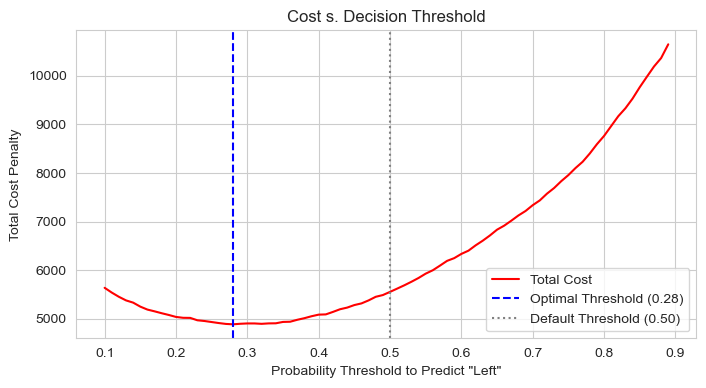

By shifting the threshold from 0.50 to 0.28, the model is optimized for false negatives.


In [57]:
xgb_probs = xgb_model.predict_proba(X_test_processed)[:, 1]

best_threshold = 0.5
min_cost = float('inf')
costs_list = []
thresholds = np.arange(0.1, 0.9, 0.01)

for t in thresholds:
    cost, fn, fp = calculate_custom_cost(y_test, xgb_probs, t)
    costs_list.append(cost)
    if cost < min_cost:
        min_cost = cost
        best_threshold = t

plt.figure(figsize=(8, 4))
plt.plot(thresholds, costs_list, label='Total Cost', color='red')
plt.axvline(x=best_threshold, color='blue', linestyle='--', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.50)')
plt.title('Cost s. Decision Threshold')
plt.xlabel('Probability Threshold to Predict "Left"')
plt.ylabel('Total Cost Penalty')
plt.legend()
plt.show()

print(f"By shifting the threshold from 0.50 to {best_threshold:.2f}, the model is optimized for false negatives.")

In [58]:
## Step 6 - Tuning

In [59]:
print("Tuning Random Forest")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1), 
    param_distributions=rf_param_grid, 
    n_iter=10, cv=3, scoring='f1', random_state=SEED, n_jobs=-1
)
rf_tuned.fit(X_train_processed, y_train)
best_rf = rf_tuned.best_estimator_
print(f"Best RF Params: {rf_tuned.best_params_}")


print("Tuning XGBoost")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb_tuned = RandomizedSearchCV(
    xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED), 
    param_distributions=xgb_param_grid, 
    n_iter=10, cv=3, scoring='f1', random_state=SEED, n_jobs=-1
)
xgb_tuned.fit(X_train_processed, y_train)
best_xgb = xgb_tuned.best_estimator_
print(f"Best XGB Params: {xgb_tuned.best_params_}")

Tuning Random Forest
Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10, 'class_weight': 'balanced'}
Tuning XGBoost
Best XGB Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}


In [60]:
print("Ensemble [XGBoost + Random Forest]")

# use soft voting
tuned_ensemble = VotingClassifier(
    estimators=[
        ('Random Forest', best_rf), 
        ('XGBoost', best_xgb)
    ],
    voting='soft'
)

print("Training Ensemble")
tuned_ensemble.fit(X_train_processed, y_train)

ensemble_preds = tuned_ensemble.predict(X_test_processed)

print("\nBase Ensemble Performance (Threshold 0.50)")
print(f"Accuracy: {accuracy_score(y_test, ensemble_preds):.4f}")
print(f"F1-Score: {f1_score(y_test, ensemble_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, ensemble_preds, target_names=['Stayed (0)', 'Left (1)']))

Ensemble [XGBoost + Random Forest]
Training Ensemble

Base Ensemble Performance (Threshold 0.50)
Accuracy: 0.7568
F1-Score: 0.7466

Classification Report:
               precision    recall  f1-score   support

  Stayed (0)       0.78      0.75      0.77      7868
    Left (1)       0.73      0.76      0.75      7032

    accuracy                           0.76     14900
   macro avg       0.76      0.76      0.76     14900
weighted avg       0.76      0.76      0.76     14900



In [61]:
ensemble_probs = tuned_ensemble.predict_proba(X_test_processed)[:, 1]

best_threshold_ens = 0.5
min_cost_ens = float('inf')

for t in np.arange(0.1, 0.9, 0.01):
    cost, fn, fp = calculate_custom_cost(y_test, ensemble_probs, t)
    if cost < min_cost_ens:
        min_cost_ens = cost
        best_threshold_ens = t

print(f"Optimized Threshold for Ensemble Found: {best_threshold_ens:.2f}")


final_optimized_preds = (ensemble_probs >= best_threshold_ens).astype(int)

print(f"Optimized Threshold: {best_threshold_ens:.2f})")
print(classification_report(y_test, final_optimized_preds, target_names=['Stayed (0)', 'Left (1)']))

# Display the Final Confusion Matrix
cm = confusion_matrix(y_test, final_optimized_preds)
print("Final Business Impact (Confusion Matrix):")
print(f"Correctly Retained (True Negatives): {cm[0][0]}")
print(f"Unnecessary Bonuses (False Positives - Minor Loss): {cm[0][1]}")
print(f"Unexpected Leavers (False Negatives - MAJOR LOSS): {cm[1][0]}")
print(f"Correctly Flagged Leavers (True Positives): {cm[1][1]}")

Optimized Threshold for Ensemble Found: 0.39
Optimized Threshold: 0.39)
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.60      0.70      7868
    Left (1)       0.66      0.88      0.76      7032

    accuracy                           0.73     14900
   macro avg       0.76      0.74      0.73     14900
weighted avg       0.76      0.73      0.73     14900

Final Business Impact (Confusion Matrix):
Correctly Retained (True Negatives): 4718
Unnecessary Bonuses (False Positives - Minor Loss): 3150
Unexpected Leavers (False Negatives - MAJOR LOSS): 819
Correctly Flagged Leavers (True Positives): 6213


## Step 7 — Explainability (SHAP & DiCE)
### SOTA MODEL ONLY
Apply explainability **only to the optimized ensembles** (Random Forest + XGBoost).

- **SHAP:** global feature importance (bar + beeswarm) and local explanations (waterfall) for the highest-risk employees.
- **DiCE:** counterfactual recommendations - *what minimal feature changes would flip a high-risk employee's prediction back to “stay”?*

## Step 8 — Final Output